## Line chart

1. Установить соединение с базой данных.

In [12]:
import pandas as pd
import sqlite3


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. SQL-запрос

In [13]:
query = """
SELECT datetime 
FROM pageviews
WHERE uid LIKE "user_%"
"""

df = pd.read_sql(query, conn)

df.head(10)

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
5,2020-04-18 12:06:13.237290
6,2020-04-18 12:06:35.574114
7,2020-04-18 12:19:50.182714
8,2020-04-18 18:14:53.813657
9,2020-04-18 18:20:05.419381


3. Группировка посещений по дате.

In [14]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["date"] = df["datetime"].dt.date

df = df.groupby('date').count().rename(columns={'datetime': 'views'})

df.head(10)

,views
date,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1
2020-04-23,5
2020-04-25,1
2020-04-26,8
2020-04-28,2


4. Построить график с использованием .plot().

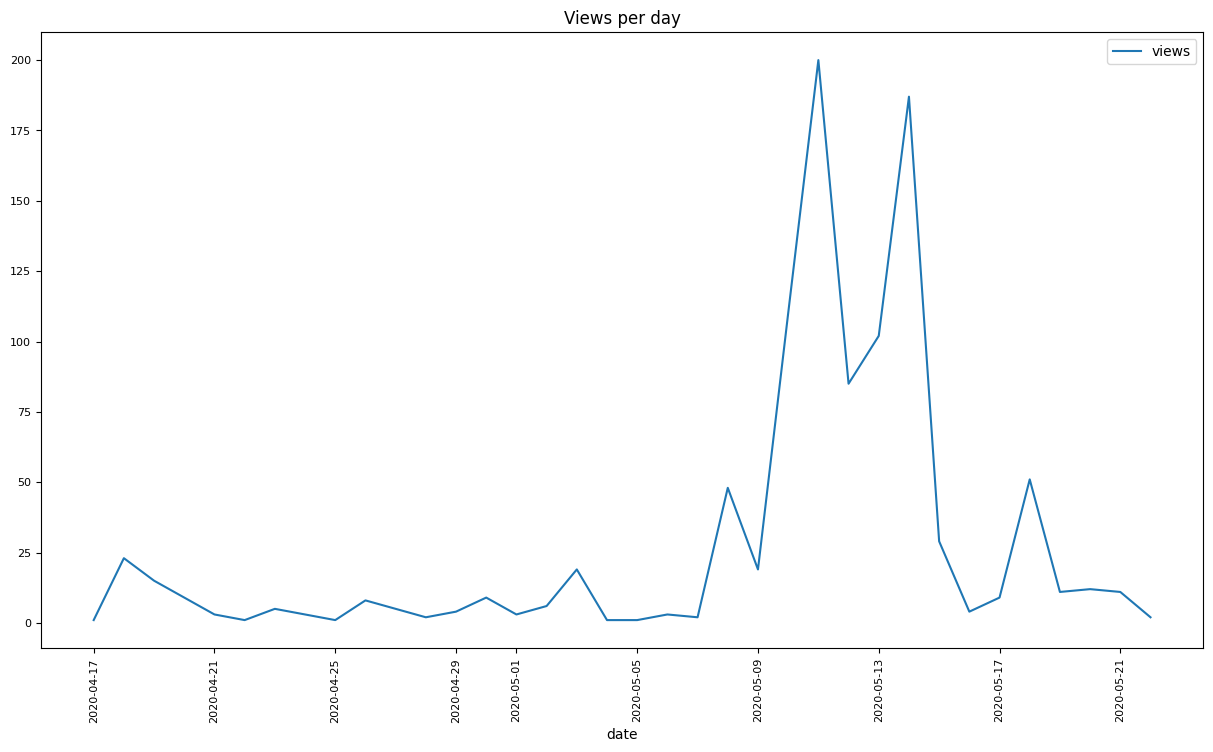

In [15]:
ax = df.plot(
    fontsize=8, 
    figsize=(15,8), 
    title="Views per day", 
    rot=90
    )

5. Закрыть соединение.

In [16]:
conn.close()

In [17]:
df.shape

(33, 1)